# 1.4.4 Smoothing Images

## Kernel Convolution

In [12]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [13]:
l=1
kernel = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]],np.float32)

In [14]:
kernel

array([[ 0., -1.,  0.],
       [-1.,  4., -1.],
       [ 0., -1.,  0.]], dtype=float32)

In [15]:
img = np.random.randint(10, size=(12,12))
#img = np.ones((10,10),np.float32)

In [16]:
img

array([[0, 8, 1, 4, 5, 8, 4, 4, 9, 2, 5, 4],
       [1, 9, 1, 6, 8, 0, 5, 9, 4, 6, 2, 7],
       [3, 5, 4, 1, 0, 6, 4, 9, 6, 5, 6, 6],
       [0, 3, 3, 9, 5, 4, 4, 5, 4, 1, 1, 0],
       [3, 6, 9, 0, 5, 7, 0, 8, 1, 8, 8, 6],
       [9, 6, 7, 7, 8, 7, 9, 5, 3, 0, 2, 1],
       [0, 3, 0, 7, 9, 9, 8, 7, 8, 9, 6, 2],
       [5, 9, 2, 9, 5, 5, 1, 8, 8, 1, 2, 8],
       [4, 5, 1, 9, 9, 1, 7, 9, 3, 8, 1, 4],
       [1, 6, 6, 2, 7, 4, 3, 8, 5, 8, 3, 8],
       [9, 2, 3, 4, 5, 3, 1, 2, 2, 5, 9, 4],
       [4, 5, 2, 7, 4, 6, 0, 7, 4, 9, 4, 4]])

In [17]:
h,w=img.shape

In [18]:
print(h,w)

12 12


In [19]:
#[*range(-2,3)]

In [20]:
dst = np.zeros((h,w),dtype = int)

In [21]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i,j]=t        

In [22]:
img

array([[0, 8, 1, 4, 5, 8, 4, 4, 9, 2, 5, 4],
       [1, 9, 1, 6, 8, 0, 5, 9, 4, 6, 2, 7],
       [3, 5, 4, 1, 0, 6, 4, 9, 6, 5, 6, 6],
       [0, 3, 3, 9, 5, 4, 4, 5, 4, 1, 1, 0],
       [3, 6, 9, 0, 5, 7, 0, 8, 1, 8, 8, 6],
       [9, 6, 7, 7, 8, 7, 9, 5, 3, 0, 2, 1],
       [0, 3, 0, 7, 9, 9, 8, 7, 8, 9, 6, 2],
       [5, 9, 2, 9, 5, 5, 1, 8, 8, 1, 2, 8],
       [4, 5, 1, 9, 9, 1, 7, 9, 3, 8, 1, 4],
       [1, 6, 6, 2, 7, 4, 3, 8, 5, 8, 3, 8],
       [9, 2, 3, 4, 5, 3, 1, 2, 2, 5, 9, 4],
       [4, 5, 2, 7, 4, 6, 0, 7, 4, 9, 4, 4]])

In [23]:
dst

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,  21, -16,  10,  21, -27,   3,  14, -14,  11, -16,   0],
       [  0,   1,   6, -15, -20,  16,  -8,  12,   2,   1,  10,   0],
       [  0,  -2, -13,  27,   2,  -6,   3,  -5,   3, -14, -11,   0],
       [  0,   3,  20, -30,   0,  12, -28,  21, -19,  22,  15,   0],
       [  0,  -1,   6,   6,   4,  -5,  16,  -7,  -2, -22,  -7,   0],
       [  0,  -3, -19,   3,   7,   7,   6,  -1,   5,  21,   9,   0],
       [  0,  21, -11,  13, -12,   4, -24,   7,  12, -23,  -8,   0],
       [  0,   0, -18,  15,  14, -21,  14,  10, -18,  19, -13,   0],
       [  0,  10,  12, -18,   8,   2,  -8,  13,  -1,  11, -14,   0],
       [  0, -15,  -2,  -1,   2,  -4,  -4, -10,  -8,  -8,  20,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]])

In [24]:
img = cv2.imread('lena.png', 0)

In [25]:
h,w=img.shape

In [26]:
dst = np.zeros((h-2*l,w-2*l),np.uint8)

In [27]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i-l,j-l]=t 

In [34]:
cv2.imshow('img',img)
cv2.imshow('dst',dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [37]:
img1 = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

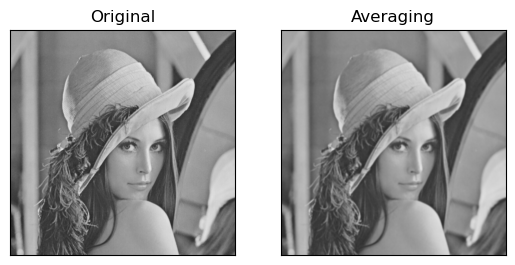

In [41]:
kernel = np.ones((5,5),np.float32)/25
#dst = cv2.filter2D(img,-1,kernel)
blur = cv2.GaussianBlur(img1,(5,5),0)
median = cv2.medianBlur(img1,5)

plt.subplot(121),plt.imshow(img1),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()